In [3]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\DELL\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Load both raw datasets
df_mat = pd.read_csv('../data/raw/student-mat.csv', sep=';')
df_por = pd.read_csv('../data/raw/student-por.csv', sep=';')

# Add a subject column to keep track of course origin before merging
df_mat['subject'] = 'math'
df_por['subject'] = 'portuguese'

# Combine both datasets into one master dataframe
df_all = pd.concat([df_mat, df_por], ignore_index=True)

# 2. Check and drop duplicate student records across both courses (if any)
# Standard UCI dataset identifies duplicates by matching demographic columns
merge_cols = ["school","sex","age","address","famsize","Pstatus","Medu","Fedu","Mjob","Fjob","reason","nursery","internet"]
df_all = df_all.drop_duplicates(subset=merge_cols)

# 3. Save clean combined data to your processed data folder
df_all.to_csv('../data/processed/cleaned_students_combined.csv', index=False)

# 4. One-Hot Encoding for categorical columns
df_encoded = pd.get_dummies(df_all, drop_first=True)

# 5. Define Features (X) and Target (y)
X = df_encoded.drop(columns=['G3'])
y = df_encoded['G3']

# 6. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("--- Complete Multi-Subject Preprocessing Finished ---")
print(f"Total Combined Student Rows: {df_all.shape[0]}")
print(f"Total Features After Encoding: {X.shape[1]}")
print(f"Training Set Size: {X_train.shape[0]} rows")
print(f"Testing Set Size:  {X_test.shape[0]} rows")

--- Complete Multi-Subject Preprocessing Finished ---
Total Combined Student Rows: 662
Total Features After Encoding: 42
Training Set Size: 529 rows
Testing Set Size:  133 rows


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load raw dataset
df = pd.read_csv('../data/raw/student-mat.csv', sep=';')

# 2. Convert categorical text columns (e.g. 'sex', 'Mjob', 'school') into numbers
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Separate Features (X) and Target Variable (y)
X = df_encoded.drop(columns=['G3'])
y = df_encoded['G3']

# 4. Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Output dataset shapes to confirm
print("--- Data Preprocessing Complete ---")
print(f"Total Features After One-Hot Encoding: {X.shape[1]}")
print(f"Training Set Size: {X_train.shape[0]} rows")
print(f"Testing Set Size:  {X_test.shape[0]} rows")


--- Data Preprocessing Complete ---
Total Features After One-Hot Encoding: 41
Training Set Size: 316 rows
Testing Set Size:  79 rows


In [6]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed successfully!")

✅ Feature scaling completed successfully!


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Initialize regression models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 2. Evaluate models on scaled data
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2 Score': r2})

# 3. Display summary dataframe
results_df = pd.DataFrame(results)
display(results_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.646666,2.378370,0.724134
1,Decision Tree,1.139241,2.050008,0.795049
2,Random Forest,1.179114,1.958256,0.812984


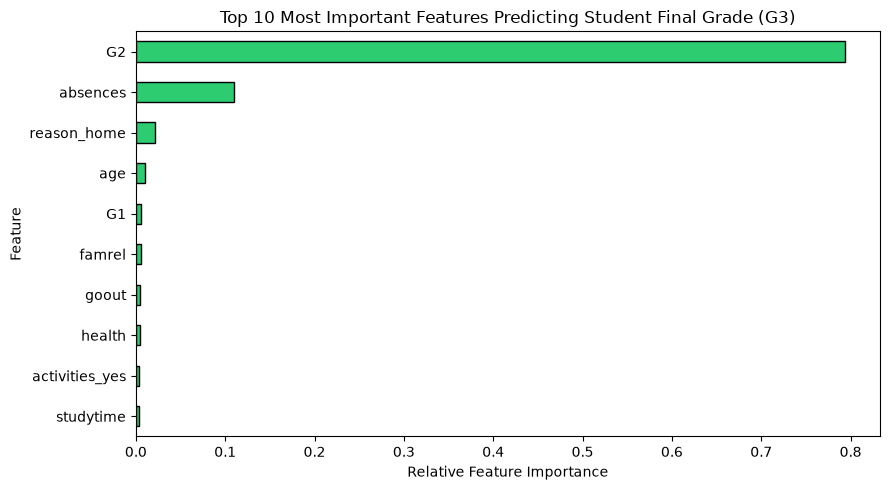

In [8]:
import matplotlib.pyplot as plt

# 1. Extract feature importances from Random Forest
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

# 2. Map to feature names and sort top 10
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True).tail(10)

# 3. Plot top 10 important features
plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color='#2ecc71', edgecolor='black')
plt.title('Top 10 Most Important Features Predicting Student Final Grade (G3)')
plt.xlabel('Relative Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()